In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import json

read_counts = ["1000", "10000", "100000"]

color_dict = {
    'covar': "#DA0754",
    'SAM_Refiner': "#047ABF",
    'crykey': '#699F38',
}

label_map = {
    'covar': 'coVar',
    'SAM_Refiner': 'SAM_Refiner',
    'crykey': 'Crykey',
}

         label        mean    stddev read_count
0  SAM_Refiner    1.115626  0.009484       1000
1        covar    0.154751  0.003473       1000
2       crykey    4.578788  0.098699       1000
3  SAM_Refiner   10.271901  0.108192      10000
4        covar    1.951891  0.025654      10000
5       crykey   13.547238  0.649843      10000
6  SAM_Refiner  117.901531  0.856961     100000
7        covar   95.814624  1.666517     100000
8       crykey  177.303097  1.402276     100000


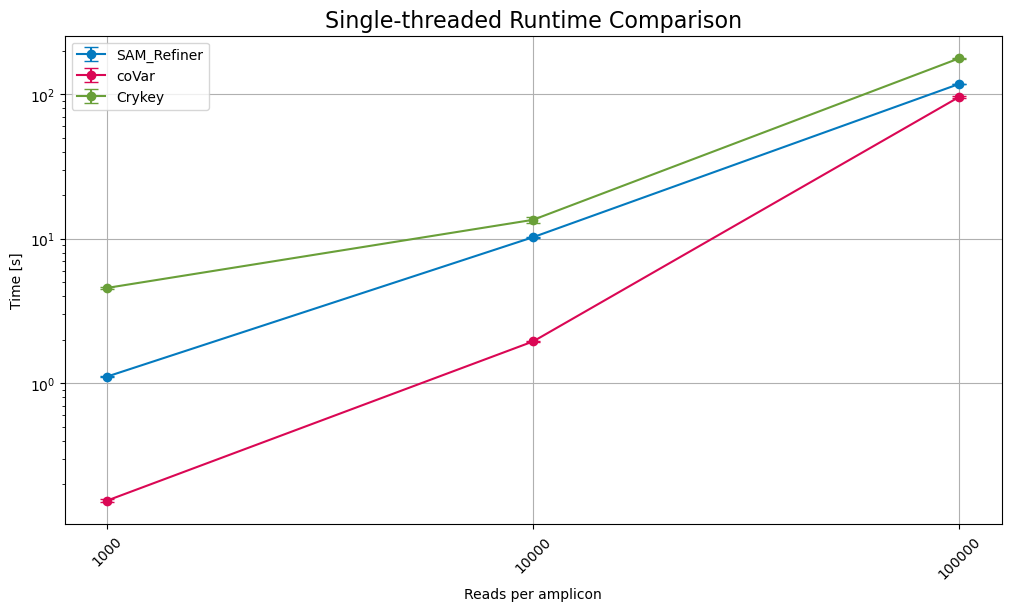

In [13]:
# Runtime comparison (single-thread)
df = pd.DataFrame()

for read_count in read_counts:

    single_thread_data = json.load(open(f'../results/single_thread_performance_{read_count}.json'))['results']
    labels = [item['command'].split(' ')[0] for item in single_thread_data]
    mean = [item['mean'] for item in single_thread_data]
    stddev = [item['stddev'] for item in single_thread_data]

    crykey_data = json.load(open(f'../results/crykey_performance_{read_count}.json'))['results']
    labels += ['crykey'] * len(crykey_data)
    mean += [item['mean'] for item in crykey_data]
    stddev += [item['stddev'] for item in crykey_data]
    
    df = pd.concat([df, pd.DataFrame({'label': labels, 'mean': mean, 'stddev': stddev, 'read_count': read_count})], ignore_index=True)

print(df)

plt.figure(figsize=(10, 6), constrained_layout=True)
for label in df['label'].unique():
    subset = df[df['label'] == label]
    # Get color from color_dict, ensuring case-insensitive matching
    color = None
    for key in color_dict:
        if key.lower() == label.lower():
            color = color_dict[key]
            break
    plt.errorbar(subset['read_count'], subset['mean'], yerr=subset['stddev'], 
                 label=label_map[label], marker='o', capsize=5, color=color)

plt.title('Single-threaded Runtime Comparison', fontsize=16)
plt.xlabel('Reads per amplicon')
plt.ylabel('Time [s]')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='medium')
#plt.ylim(0, None)
plt.yscale('log')
plt.grid(True)
plt.savefig('../results/single_thread_performance.pdf', bbox_inches='tight', dpi=300)
plt.show()

         label       mean    stddev read_count
0  SAM_Refiner   1.136858  0.009772       1000
1        covar   0.097257  0.004199       1000
2  SAM_Refiner  10.310918  0.058003      10000
3        covar   0.822235  0.008915      10000
4  SAM_Refiner  81.256241  0.353996     100000
5        covar  17.628577  0.487910     100000


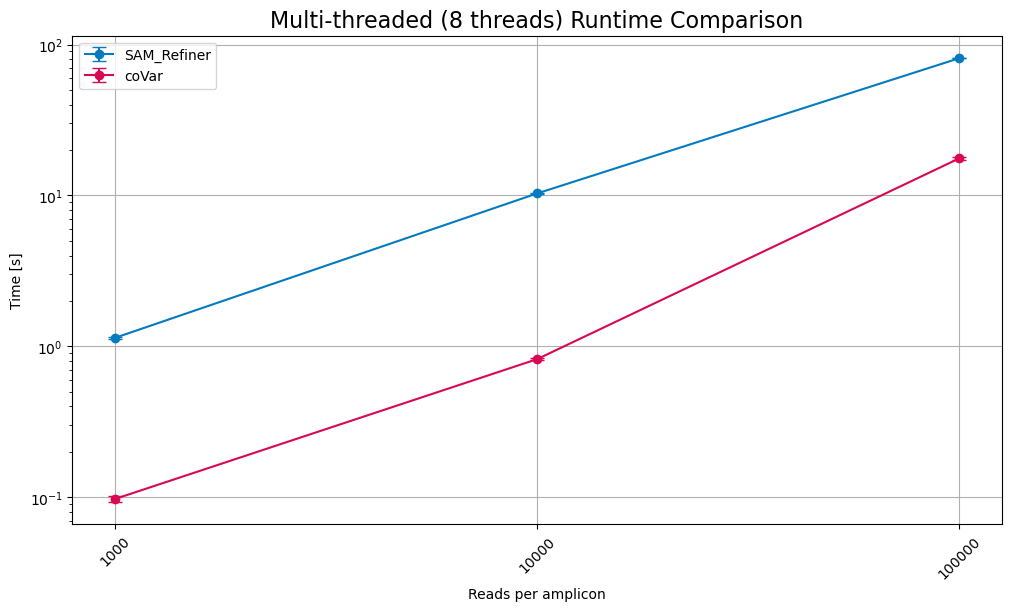

In [14]:
# Runtime comparison (multi-thread)
read_counts = ["1000", "10000", "100000"]

df = pd.DataFrame()

for read_count in read_counts:

    multi_thread_data = json.load(open(f'../results/multi_thread_performance_{read_count}.json'))['results']
    labels = [item['command'].split(' ')[0] for item in multi_thread_data]

    mean = [item['mean'] for item in multi_thread_data]
    stddev = [item['stddev'] for item in multi_thread_data]

    df = pd.concat([df, pd.DataFrame({'label': labels, 'mean': mean, 'stddev': stddev, 'read_count': read_count})], ignore_index=True)

print(df)

plt.figure(figsize=(10, 6), constrained_layout=True)
for label in df['label'].unique():
    color = None
    for key in color_dict:
        if key.lower() == label.lower():
            color = color_dict[key]
            break
    subset = df[df['label'] == label]
    color = color_dict.get(label)
    plt.errorbar(subset['read_count'], subset['mean'], yerr=subset['stddev'], label=label_map[label], marker='o', capsize=5, color=color)
plt.title('Multi-threaded (8 threads) Runtime Comparison', fontsize=16)
plt.xlabel('Reads per amplicon')
plt.ylabel('Time [s]')
plt.xticks(rotation=45)
plt.legend(loc='best', fontsize='medium')
plt.yscale('log')
plt.grid(True)
plt.savefig('../results/multi_thread_performance.pdf', bbox_inches='tight', dpi=300)
plt.show()